In [1]:
# Equations (Stochastic Differential Equations)- stock price dynamics and volatility dynamics

import numpy as np
import matplotlib.pyplot as plt

# Parameters of both equations
T = 1.0 # Total time
N = 1000 # Number of time steps
dt = T / N # Time step size
t = np.linspace(0.0, T, N+1) # Time vector
mu = 0.1 # Expected return
v0 = 0.1 # Initial volatility
kappa = 3.0 # Mean reversion rate
theta = 0.2 # Long-term average volatility
sigma = 0.1 # Volatility

# Generate random shocks - random fluctuations
dW1 = np.random.randn(N) * np.sqrt(dt)
dW2 = np.random.randn(N) * np.sqrt(dt)

# Initialize arrays for stock price and volatility
S = np.zeros(N+1)
v = np.zeros(N+1)
S[0] = 100.0 # Initial stock price
v[0] = v0 # Initial volatility

# Euler-Maruyama method to solve the stochastic differential equation for stock price dynamics
for i in range(1, N+1):
    v[i] = v[i-1] + kappa * (theta - v[i-1]) * dt + sigma * np.sqrt(v[i-1]) * dW2[i-1]
    S[i] = S[i-1] * (1 + mu * dt + np.sqrt(v[i-1]) * dW1[i-1])


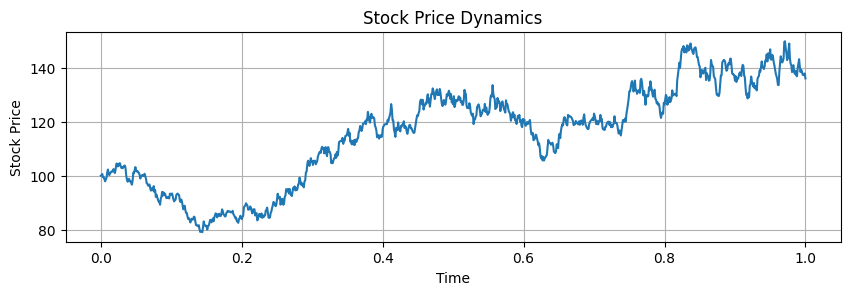

In [2]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, S)
plt.title('Stock Price Dynamics')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.grid(True)


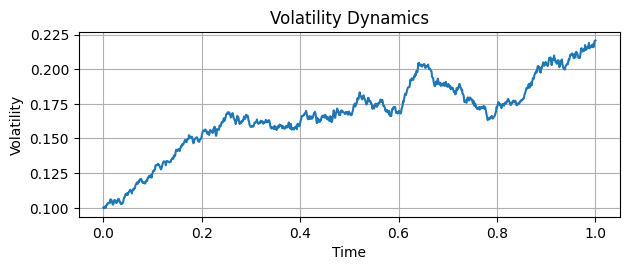

In [3]:

plt.subplot(2, 1, 2)
plt.plot(t, v)
plt.title('Volatility Dynamics')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from scipy.integrate import quad


In [5]:
# Model parameters
S0 = 100.0    # Initial stock price
K = 100.0     # Strike price
r = 0.05      # Risk-free rate
T = 1.0       # Time to maturity
kappa = 2.0   # Mean reversion rate
theta = 0.05  # Long-term average volatility
sigma = 0.3   # Volatility of volatility
rho = -0.5    # Correlation coefficient
v0 = 0.05     # Initial volatility

In [6]:
def heston_characteristic_function(u, S0, K, r, T, kappa, theta, sigma, rho, v0):
    xi = kappa - rho * sigma * 1j * u
    d = np.sqrt((rho * sigma * 1j * u - xi)**2 - sigma**2 * (-u * 1j - u**2))
    g = (xi - rho * sigma * 1j * u - d) / (xi - rho * sigma * 1j * u + d)
    C = r * 1j * u * T + (kappa * theta) / sigma**2 * ((xi - rho * sigma * 1j * u - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))
    D = (xi - rho * sigma * 1j * u - d) / sigma**2 * ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))
    return np.exp(C + D * v0 + 1j * u * np.log(S0))


In [7]:
def heston_call_price(S0, K, r, T, kappa, theta, sigma, rho, v0):
    integrand = lambda u: np.real(np.exp(-1j * u * np.log(K)) / (1j * u) * heston_characteristic_function(u - 1j, S0, K, r, T, kappa, theta, sigma, rho, v0))
    integral, _ = quad(integrand, 0, np.inf)
    return np.exp(-r * T) * 0.5 * S0 - np.exp(-r * T) / np.pi * integral

def heston_put_price(S0, K, r, T, kappa, theta, sigma, rho, v0):
    integrand = lambda u: np.real(np.exp(-1j * u * np.log(K)) / (1j * u) * heston_characteristic_function(u - 1j, S0, K, r, T, kappa, theta, sigma, rho, v0))
    integral, _ = quad(integrand, 0, np.inf)
    return np.exp(-r * T) / np.pi * integral - S0 + K * np.exp(-r * T)


In [8]:
# Calculate call and put option prices
call_price = heston_call_price(S0, K, r, T, kappa, theta, sigma, rho, v0)
put_price = heston_put_price(S0, K, r, T, kappa, theta, sigma, rho, v0)

print("European Call Option Price:", np.round(call_price, 2))
print("European Put Option Price:", np.round(put_price, 2))

European Call Option Price: 27.63
European Put Option Price: 15.06
